In [6]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [2]:
#load the source file that contains the data. 
df = pd.read_csv("C:/Users/hp/Downloads/inventory_demand_stockout_risk.csv")
df['date'] = pd.to_datetime(df['date'])
df.head()

,product_id,date,store_id,current_stock,daily_demand,lead_time_days,supplier_reliability_score,promotion_active,weather_impact,stockout_risk
0,P1000,2024-01-01,S7,213,114,5,72,No,Medium,No
1,P1001,2024-01-02,S20,152,87,7,84,No,High,Yes
2,P1002,2024-01-03,S15,209,62,10,61,No,Low,No
3,P1003,2024-01-04,S11,400,103,10,61,No,Low,No
4,P1004,2024-01-05,S8,60,114,9,75,No,Medium,No


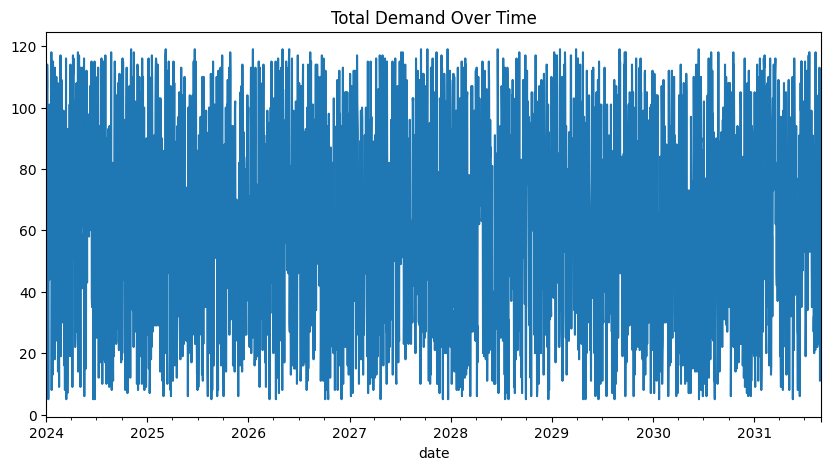

In [4]:
#visualise annual demand over time
df.groupby('date')['daily_demand'].sum().plot(figsize=(10,5))
plt.title("Total Demand Over Time")
plt.show()

In [5]:
#feature engineering
df['day_of_week'] = df['date'].dt.dayofweek
df['lag_1'] = df['daily_demand'].shift(1)
df['lag_7'] = df['daily_demand'].shift(7)

df = df.dropna()

In [7]:
#split the data into training and testing data sets (80% training dataset and 20% test dataset.
#calculate the mean absolute error - measures error in the predicted value vs actual. 
features = ['lag_1', 'lag_7', 'day_of_week']

X = df[features]
y = df['daily_demand']

split = int(len(df)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = RandomForestRegressor()
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))

MAE: 31.00234719737627
